In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

tb = pd.read_csv('BaseFeminicidioEvolucaoMensalCisp.csv', sep = ';', encoding="UTF-8")

#Filtra a tabela para que começe a partir do Mês 11 de 2023
filtroAno23 = ((tb['Ano'] == 2023) & (tb['M�s'] > 10)) | (tb['Ano'] > 2023)
tbFiltrado23 = tb[filtroAno23]

#Filtro para focar só nas Regiôes da Grande Niterói e Região dos Lagos(AISP = 4)
#Tabela filtrada
filtroNit23 = (((tb['Ano'] == 2023) & (tb['M�s'] > 10)) | (tb['Ano'] > 2023)) & (tb['RISP'] == 4)
tbNit23 = tb[filtroNit23]

#Variaveis para guardar os 
FemNit23 = tbNit23['Feminic�dio'].sum()
TentNit23 = tbNit23['Tentativa de feminic�dio'].sum()

#pd.to_numeric PEGA A COLUNA 'ANO' E TRANSFORMA EM INTEIRO
#np.array TRANSFORMA ESSES NUMEROS NUM ARRAY E REMOVE OS NUMEROS DUPLICADOS
Anos23 = pd.to_numeric(tb['Ano'], errors='coerce')
Anos23 = np.array(Anos23.drop_duplicates())
Anos23 = Anos23[Anos23 > 2022]

#Variaveis para somar e savlar os Feminicidios e as Tentaticas por Ano 
TotalFemPAno23 = []
TotalTentaPAno23 = []

#Loop para separar cada Ano e somar os dados
for i in range(Anos23.size):
  TotalFemPAno23.append([tbFiltrado23.loc[tbFiltrado23['Ano'] == Anos23[i], 'Feminic�dio'].sum()])
  TotalTentaPAno23.append([tbFiltrado23.loc[tbFiltrado23['Ano'] == Anos23[i], 'Tentativa de feminic�dio'].sum()])

#Porcerntagem do aumento do feminicidio 
#Aumento de 47%
#RJ 2016 = 161 = 100%
#RJ 2023 = 237 = 147%

#Aumento de 66%
#Nit 2016 = 21 = 100%
#Nit 2023 = 35 = 166%

#Tentativa
#Aumento de 24%
#RJ 2016 = 642 = 100%
#RJ 2023 = 802 = 124%

#Aumento de 34%
#Nit 2016 = 101 = 100%
#Nit 2023 = 136 = 134%

Feminicidios registrados nos anos de 2026 : 12
Feminicidios registrados nos anos de 2025 : 105
Feminicidios registrados nos anos de 2024 : 107
Feminicidios registrados nos anos de 2023 : 13
Feminicidios registrados em Niterói e Região dos lagos (2023-2026): 35


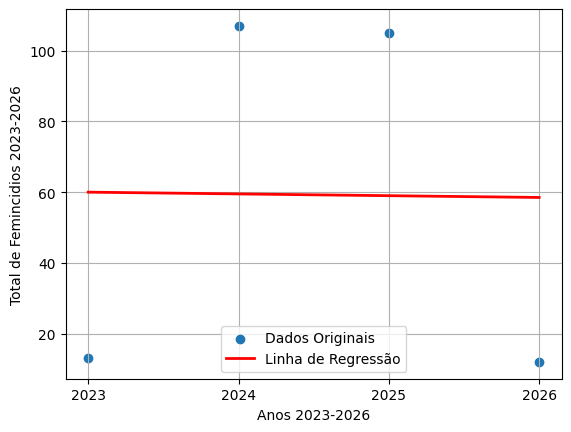

In [32]:
#USANDO O NUMPY PARA CALCULAR O INTERCEPTO E COEFICIENTE ANGULAR
cAngularFemin23, interFemin23 = np.polyfit(Anos23, TotalFemPAno23, 1)

#CALCULANDO O PREVISTO
FeminPred2023 = cAngularFemin23 * Anos23 + interFemin23

#FAZENDO O GRÁFICO DA REGRESSÃO LINEAR
plt.scatter(Anos23, TotalFemPAno23, label = 'Dados Originais')
plt.plot(Anos23, FeminPred2023, color = 'red', linewidth = 2, label = 'Linha de Regressão')

#ESSA FUNÇÃO REMOVE OS NÚMEROS QUEBRADOS NO EIXO X, POR EXEMPLO, ANTES HAVIA 2025.5
plt.xticks(np.arange(min(Anos23), max(Anos23)+1, 1.0))

plt.xlabel('Anos 2023-2026')
plt.ylabel('Total de Femincidios 2023-2026')
plt.legend()
#plt.title('Regressão Linear do total de Femincídios entre 2023 à 2026')
plt.grid(True)


for i in range(Anos23.size):
  print('Feminicidios registrados nos anos de',Anos23[i], ':', *TotalFemPAno23[i])

print('Feminicidios registrados em Niterói e Região dos lagos (2023-2026):', FemNit23)


Tentativas registradas no ano de 2026 : 57
Tentativas registradas no ano de 2025 : 307
Tentativas registradas no ano de 2024 : 382
Tentativas registradas no ano de 2023 : 56
Tentativas registrados em Niterói (2023-2026) 136


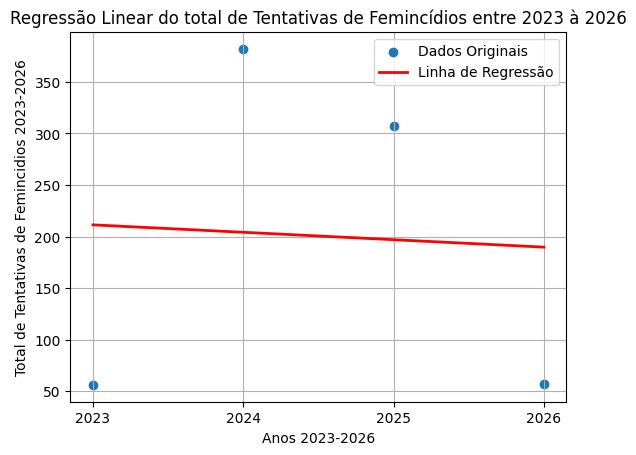

In [ ]:
#REGRESSÃO LINEAR TENTATIVA


cAngularTenta23, interTenta23 = np.polyfit(Anos23, TotalTentaPAno23, 1)

TentaPred2023 = cAngularTenta23 * Anos23 + interTenta23

plt.scatter(Anos23, TotalTentaPAno23, label = 'Dados Originais')
plt.plot(Anos23, TentaPred2023, color = 'red', linewidth = 2, label = 'Linha de Regressão')

#ESSA FUNÇÃO REMOVE OS NÚMEROS QUEBRADOS NO EIXO X, POR EXEMPLO, ANTES HAVIA 2025.5
plt.xticks(np.arange(min(Anos23), max(Anos23)+1, 1.0))

plt.xlabel('Anos 2023-2026')
plt.ylabel('Total de Tentativas de Femincidios 2023-2026')
plt.legend()
plt.title('Regressão Linear do total de Tentativas de Femincídios entre 2023 à 2026')
plt.grid(True)

for i in range(Anos23.size):
  print('Tentativas registradas no ano de',Anos23[i], ':', *TotalTentaPAno23[i])

print('Tentativas registrados em Niterói e Região dos lagos (2023-2026):', TentNit23)

In [34]:
#2016 à 2019
#Criado outra tabela para filtrar a tabela salvando apenas os anos a partir de 2019 no mês 2
filtroAno16 = (tb['Ano'] < 2019) | ((tb['Ano'] == 2019) & (tb['M�s'] < 3))
tbFiltrado16 = tb[filtroAno16]

Anos16 = pd.to_numeric(tb['Ano'], errors='coerce')
Anos16 = np.array(Anos16.drop_duplicates())
Anos16 = Anos16[Anos16 < 2020]

filtroNit16 = ((tb['Ano'] < 2019) | ((tb['Ano'] == 2019) & (tb['M�s'] < 3))) & (tb['RISP'] == 4)
tbNit16 = tb[filtroNit16]

#Variaveis para guardar os 
FemNit16 = tbNit16['Feminic�dio'].sum()
TentNit16 = tbNit16['Tentativa de feminic�dio'].sum()

TotalFemPAno16 = []
TotalTentaPAno16 = []

#Loop para separar cada Ano e somar os dados
for i in range(Anos16.size):
  TotalFemPAno16.append([tbFiltrado16.loc[tbFiltrado16['Ano'] == Anos16[i], 'Feminic�dio'].sum()])
  TotalTentaPAno16.append([tbFiltrado16.loc[tbFiltrado16['Ano'] == Anos16[i], 'Tentativa de feminic�dio'].sum()])



Feminicidios registrados nos anos de 2019 : 8
Feminicidios registrados nos anos de 2018 : 71
Feminicidios registrados nos anos de 2017 : 68
Feminicidios registrados nos anos de 2016 : 14
Feminicidios registrados em Niterói e Regiãos dos lagos (2016-2019): 21


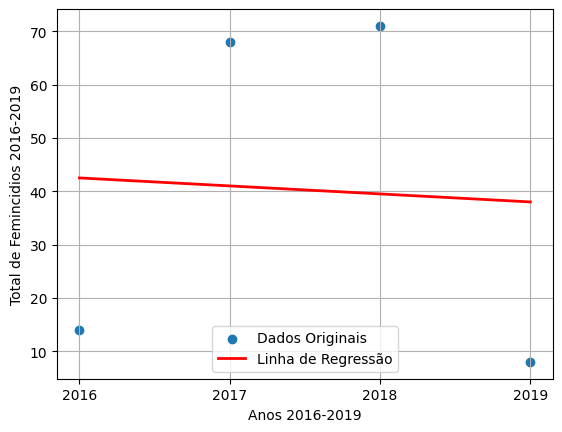

In [35]:
cAngularFemin16, interFemin16 = np.polyfit(Anos16, TotalFemPAno16, 1)

FeminPred16 = cAngularFemin16 * Anos16 + interFemin16

plt.scatter(Anos16, TotalFemPAno16, label = 'Dados Originais')
plt.plot(Anos16, FeminPred16, color = 'red', linewidth = 2, label = 'Linha de Regressão')

plt.xticks(np.arange(min(Anos16), max(Anos16)+1, 1.0))

plt.xlabel('Anos 2016-2019')
plt.ylabel('Total de Femincidios 2016-2019')
plt.legend()
plt.grid(True)


for i in range(Anos16.size):
  print('Feminicidios registrados nos anos de',Anos16[i], ':', *TotalFemPAno16[i])

print('Feminicidios registrados em Niterói e Regiãos dos lagos (2016-2019):', FemNit16)  

Tentativas de feminicidios registrados nos anos de 2019 : 63
Tentativas de feminicidios registrados nos anos de 2018 : 288
Tentativas de feminicidios registrados nos anos de 2017 : 248
Tentativas de feminicidios registrados nos anos de 2016 : 43
Tentativas de feminicidios registrados em Niterói e Regiãos dos lagos (2016-2019): 101


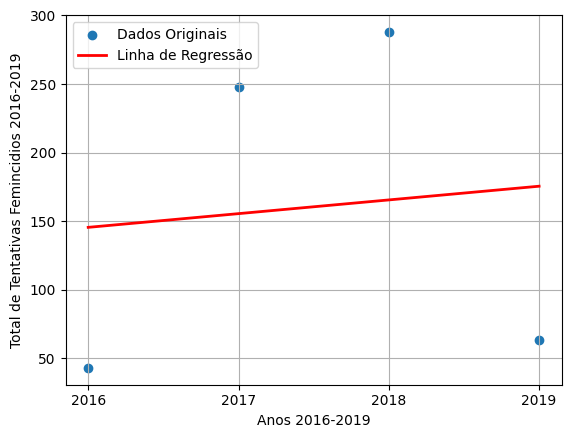

In [33]:
cAngularTenta16, interTenta16 = np.polyfit(Anos16, TotalTentaPAno16, 1)

TentaPred16 = cAngularTenta16 * Anos16 + interTenta16

plt.scatter(Anos16, TotalTentaPAno16, label = 'Dados Originais')
plt.plot(Anos16, TentaPred16, color = 'red', linewidth = 2, label = 'Linha de Regressão')

plt.xticks(np.arange(min(Anos16), max(Anos16)+1, 1.0))

plt.xlabel('Anos 2016-2019')
plt.ylabel('Total de Tentativas Femincidios 2016-2019')
plt.legend()
plt.grid(True)


for i in range(Anos16.size):
  print('Tentativas de feminicidios registrados nos anos de',Anos16[i], ':', *TotalTentaPAno16[i])

print('Tentativas de feminicidios registrados em Niterói e Regiãos dos lagos (2016-2019):', TentNit16)  